# Forecasting


## Goal

Forecast future BMW `Units_Sold` using monthly historical sales data.

Models compared:
1. Exponential Smoothing
2. ARIMA
3. Prophet

The notebook uses a train/test split to compare model accuracy before generating a 24-month forecast.


In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Objective : 

1) Forecast BMW vehicle sales for the next 12–24 months using historical sales data to identify growth trends and support business planning.

In [162]:
df = pd.read_csv("../data/bmw_global_sales_2018_2025_cleaned.csv", parse_dates=["Date"] )
df.head(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,January,Europe,3 Series,7822,47482.0,371404204.0,0.011,19.12,3.5,1.0,2018-01-01
1,2018,January,Europe,5 Series,10280,61685.0,634121800.0,0.019,19.12,3.5,1.0,2018-01-01
2,2018,January,Europe,X3,3105,58433.0,181434465.0,0.022,19.12,3.5,1.0,2018-01-01
3,2018,January,Europe,X5,7420,67955.0,504226100.0,0.021,19.12,3.5,1.0,2018-01-01
4,2018,January,Europe,X7,8474,92300.0,782150200.0,0.035,19.12,3.5,1.0,2018-01-01


In [163]:
# Aggreate sales by month
sales = df.groupby("Date")["Units_Sold"].sum().reset_index()
print(sales)


         Date  Units_Sold
0  2018-01-01      230195
1  2018-02-01      201033
2  2018-03-01      250912
3  2018-04-01      249552
4  2018-05-01      218362
..        ...         ...
91 2025-08-01      260474
92 2025-09-01      306776
93 2025-10-01      237864
94 2025-11-01      285728
95 2025-12-01      299002

[96 rows x 2 columns]


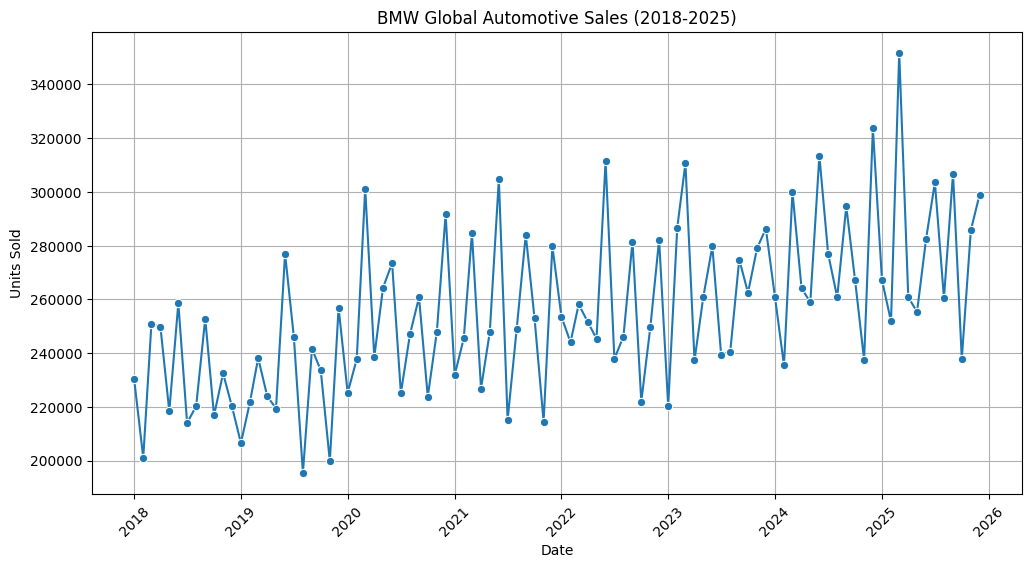

In [164]:
# Visualize sales trend

plt.figure(figsize=(12, 6))
sns.lineplot(x="Date", y="Units_Sold", data=sales, marker="o")
plt.title("BMW Global Automotive Sales (2018-2025)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [165]:
from prophet import Prophet

prophet_df = sales.rename(columns={'Date' : 'ds', 'Units_Sold' : 'y'})
print(prophet_df.head())

          ds       y
0 2018-01-01  230195
1 2018-02-01  201033
2 2018-03-01  250912
3 2018-04-01  249552
4 2018-05-01  218362


In [166]:
model = Prophet()
model.fit(prophet_df)

# future Dates
future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

# ds = Date
# yhat = Predicted sales (predicted number of units sold)
# yhat_lower = Lower confidence interval
# yhat_upper = Upper confidence interval

00:52:27 - cmdstanpy - INFO - Chain [1] start processing
00:52:27 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat     yhat_lower     yhat_upper
108 2026-12-31  277183.490073  257213.140609  297575.908132
109 2027-01-31  302682.297305  283567.278670  321843.156340
110 2027-02-28  294576.756420  274549.684592  313980.239678
111 2027-03-31  299714.547384  280527.117733  318498.981351
112 2027-04-30  283568.599086  262905.867476  303270.142276
113 2027-05-31  339733.732567  318214.689421  359651.223329
114 2027-06-30  291353.684186  270946.615475  311541.515130
115 2027-07-31  245953.197753  225532.616820  266476.017743
116 2027-08-31  305791.850440  285167.387096  325514.721172
117 2027-09-30  307880.340075  286353.168037  327198.933056
118 2027-10-31  308479.471633  287730.073636  328189.743499
119 2027-11-30  276390.303225  254738.245821  295178.237744


1) yhat → the model’s best estimate (expected value)
2) yhat_lower → lower bound of the prediction interval
3) yhat_upper → upper bound of the prediction interval

By default, Prophet gives an 80% uncertainty interval (configurable via interval_width).

4) There is an ~80% probability that the true value will fall between yhat_lower and yhat_upper.

Example: 
Suppose for Jan 2027 your forecast outputs:

yhat = 10,000

yhat_lower = 8,500

yhat_upper = 11,500

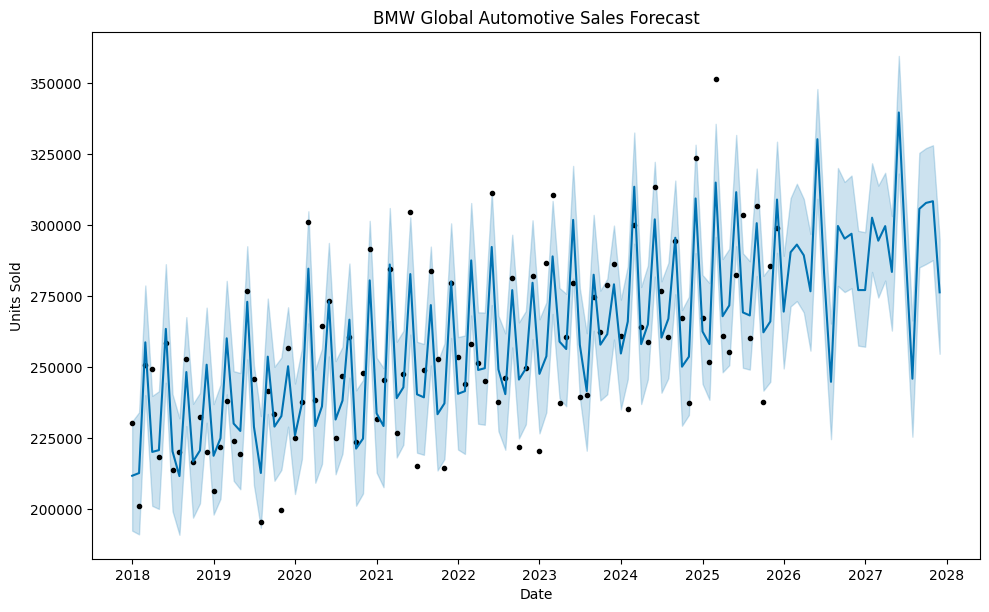

In [167]:
model.plot(forecast)
plt.title("BMW Global Automotive Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")    
plt.grid()
plt.show()

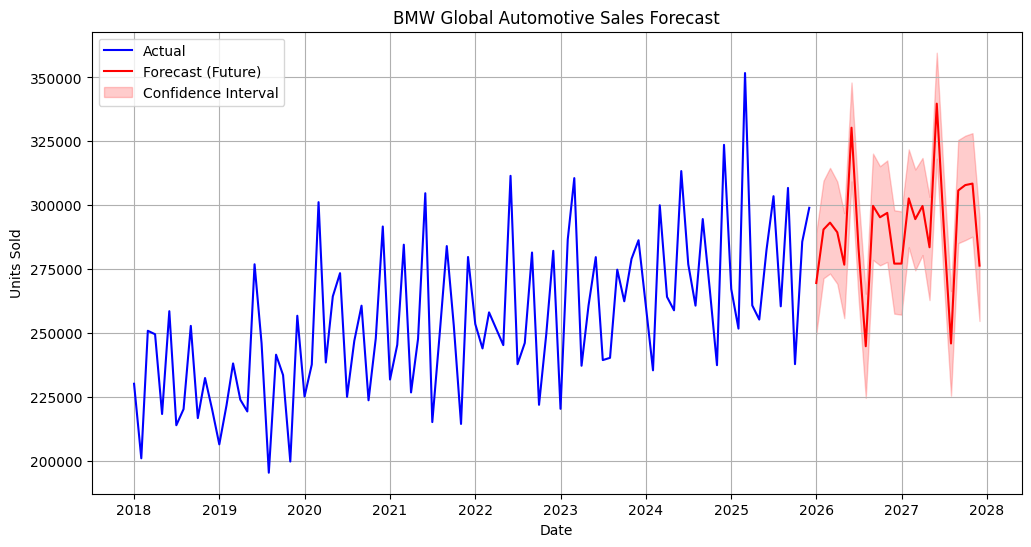

In [168]:
import matplotlib.pyplot as plt

# Split data
historical = forecast[forecast['ds'] <= prophet_df['ds'].max()]
future_pred = forecast[forecast['ds'] > prophet_df['ds'].max()]

plt.figure(figsize=(12,6))

# Actual data (blue)
plt.plot(prophet_df['ds'], prophet_df['y'], label='Actual', color='blue')

# Forecast (red)
plt.plot(future_pred['ds'], future_pred['yhat'], label='Forecast (Future)', color='red')

# Optional: confidence interval shading
plt.fill_between(
    future_pred['ds'],
    future_pred['yhat_lower'],
    future_pred['yhat_upper'],
    color='red',
    alpha=0.2,
    label='Confidence Interval'
)

plt.title("BMW Global Automotive Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid()
plt.show()


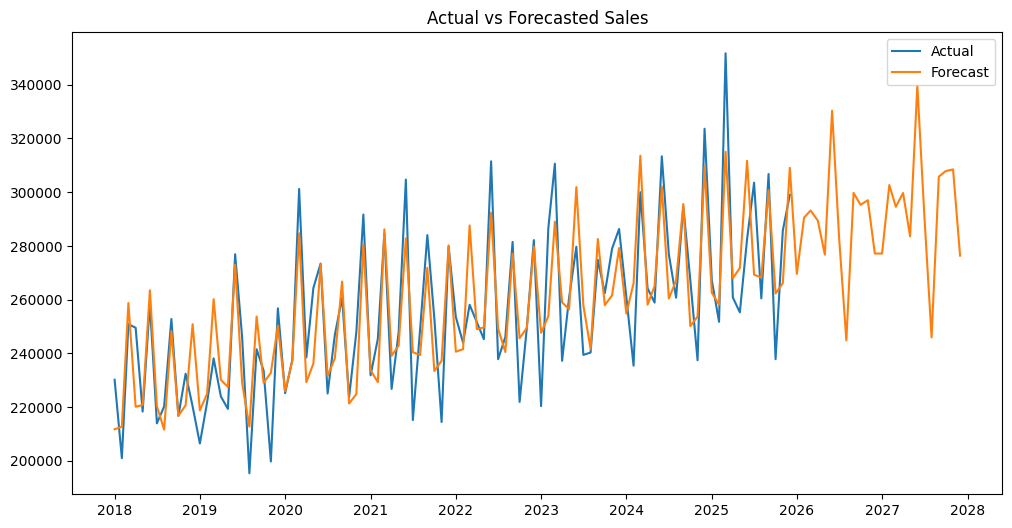

In [169]:
plt.figure(figsize=(12,6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast")
plt.legend()
plt.title("Actual vs Forecasted Sales")
plt.show()

## Forecast Conclusions

The 24-month Prophet forecast suggests BMW sales should remain broadly stable with recurring seasonal fluctuations rather than a sharp breakout trend. Expected peaks and dips continue to follow the historical monthly pattern, so the main signal is seasonality on top of modest long-term growth.

Key takeaways:
- Sales are projected to stay within a fairly consistent band over the next 24 months.
- Seasonal highs and lows remain visible in the forecast.
- The uncertainty interval shows that month-to-month variation is meaningful, so projections should be treated as a planning range rather than an exact point estimate.
- Historical backtesting is still necessary before selecting Prophet as the production model.


# Moving Averages

In [170]:
train = sales[sales['Date'] <= '2022-12-01'].copy()
test = sales[sales['Date'] >= '2023-01-01'].copy()

print('Train set:')
print(train)

print('\nTest set:')
print(test)


Train set:
         Date  Units_Sold
0  2018-01-01      230195
1  2018-02-01      201033
2  2018-03-01      250912
3  2018-04-01      249552
4  2018-05-01      218362
5  2018-06-01      258576
6  2018-07-01      213966
7  2018-08-01      220279
8  2018-09-01      252828
9  2018-10-01      216765
10 2018-11-01      232445
11 2018-12-01      220280
12 2019-01-01      206484
13 2019-02-01      221810
14 2019-03-01      238150
15 2019-04-01      223963
16 2019-05-01      219363
17 2019-06-01      276921
18 2019-07-01      246019
19 2019-08-01      195402
20 2019-09-01      241565
21 2019-10-01      233591
22 2019-11-01      199779
23 2019-12-01      256791
24 2020-01-01      225213
25 2020-02-01      237704
26 2020-03-01      301212
27 2020-04-01      238510
28 2020-05-01      264352
29 2020-06-01      273455
30 2020-07-01      225084
31 2020-08-01      246949
32 2020-09-01      260725
33 2020-10-01      223727
34 2020-11-01      247930
35 2020-12-01      291695
36 2021-01-01      231854
3

# Method 1 : Moving Average / Exponential Smoothing

In [171]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ExponentialSmoothing expects a numeric series (not a DataFrame)
model_es = ExponentialSmoothing(train["Units_Sold"].astype(float), trend="add", seasonal=None)
model_es_fit = model_es.fit()
pred_es = model_es_fit.forecast(steps=len(test))
print(pred_es)

60    261400.480332
61    261906.982851
62    262413.485371
63    262919.987890
64    263426.490410
65    263932.992929
66    264439.495449
67    264945.997968
68    265452.500488
69    265959.003007
70    266465.505527
71    266972.008046
72    267478.510566
73    267985.013085
74    268491.515605
75    268998.018124
76    269504.520644
77    270011.023163
78    270517.525683
79    271024.028202
80    271530.530722
81    272037.033241
82    272543.535761
83    273050.038280
84    273556.540800
85    274063.043319
86    274569.545839
87    275076.048358
88    275582.550878
89    276089.053397
90    276595.555917
91    277102.058436
92    277608.560956
93    278115.063475
94    278621.565995
95    279128.068514
dtype: float64


# Model 2 — ARIMA

In [172]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train["Units_Sold"].astype(float), order=(1, 1, 1))
model_arima_fit = model_arima.fit()
pred_arima = model_arima_fit.forecast(steps=len(test))
print(pred_arima)

60    260433.741045
61    261025.823078
62    261009.705517
63    261010.144267
64    261010.132323
65    261010.132648
66    261010.132639
67    261010.132639
68    261010.132639
69    261010.132639
70    261010.132639
71    261010.132639
72    261010.132639
73    261010.132639
74    261010.132639
75    261010.132639
76    261010.132639
77    261010.132639
78    261010.132639
79    261010.132639
80    261010.132639
81    261010.132639
82    261010.132639
83    261010.132639
84    261010.132639
85    261010.132639
86    261010.132639
87    261010.132639
88    261010.132639
89    261010.132639
90    261010.132639
91    261010.132639
92    261010.132639
93    261010.132639
94    261010.132639
95    261010.132639
Name: predicted_mean, dtype: float64


# Model 3 — Prophet 


In [173]:
from prophet import Prophet

prophet_df = sales.rename(columns={'Date': 'ds', 'Units_Sold': 'y'})
print(prophet_df.head())

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_prophet.fit(prophet_df[prophet_df['ds'] <= '2022-12-01'])

future_prophet = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
pred_prophet = model_prophet.predict(future_prophet)
pred_prophet = pred_prophet[pred_prophet['ds'] >= '2023-01-01'].reset_index(drop=True)

print(pred_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())


00:52:28 - cmdstanpy - INFO - Chain [1] start processing


          ds       y
0 2018-01-01  230195
1 2018-02-01  201033
2 2018-03-01  250912
3 2018-04-01  249552
4 2018-05-01  218362


00:52:28 - cmdstanpy - INFO - Chain [1] done processing


          ds           yhat     yhat_lower     yhat_upper
0 2023-01-01  254257.869453  239079.805729  269434.343370
1 2023-02-01  258401.309623  243334.196817  273533.321027
2 2023-03-01  272203.012102  256548.364437  287758.705201
3 2023-04-01  270899.014099  255082.910095  286699.959275
4 2023-05-01  249284.410175  233863.723371  266146.385701


# Evaluation of model

In [174]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

y_true = test['Units_Sold']

es_mae, es_rmse = evaluate(y_true, pred_es)
arima_mae, arima_rmse = evaluate(y_true, pred_arima)

prophet_eval = test.merge(
    pred_prophet[['ds', 'yhat']],
    left_on='Date',
    right_on='ds',
    how='left'
).dropna(subset=['yhat'])

prophet_mae, prophet_rmse = evaluate(prophet_eval['Units_Sold'], prophet_eval['yhat'])

print(prophet_eval.head())


        Date  Units_Sold         ds           yhat
0 2023-01-01      220386 2023-01-01  254257.869453
1 2023-02-01      286648 2023-02-01  258401.309623
2 2023-03-01      310618 2023-03-01  272203.012102
3 2023-04-01      237237 2023-04-01  270899.014099
4 2023-05-01      260803 2023-05-01  249284.410175


In [175]:
results = pd.DataFrame({
    "Model": ["Exponential Smoothing", "ARIMA", "Prophet"],
    "MAE": [es_mae, arima_mae, prophet_mae],
    "RMSE": [es_rmse, arima_rmse, prophet_rmse]
})

print(results)

                   Model           MAE          RMSE
0  Exponential Smoothing  22186.971130  27415.943169
1                  ARIMA  23093.376682  30664.911649
2                Prophet  19779.594122  23835.172477


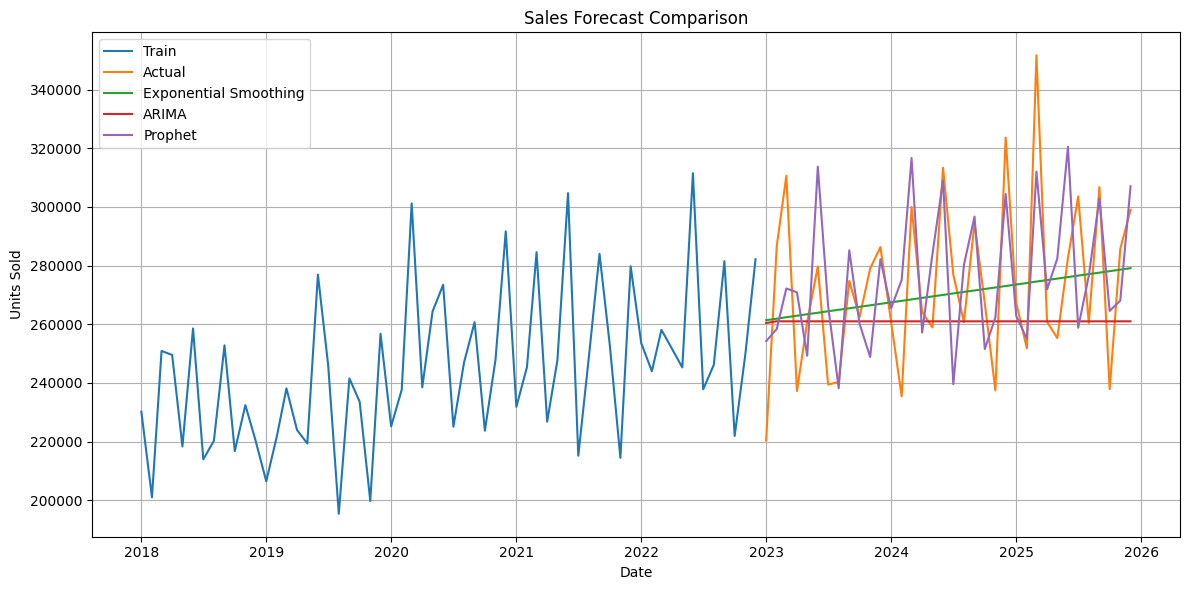

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train['Date'], train['Units_Sold'], label='Train')
plt.plot(test['Date'], test['Units_Sold'], label='Actual')
plt.plot(test['Date'], pred_es, label='Exponential Smoothing')
plt.plot(test['Date'], pred_arima, label='ARIMA')
plt.plot(prophet_eval['Date'], prophet_eval['yhat'], label='Prophet')

plt.legend()
plt.title('Sales Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.grid(True)
plt.tight_layout()
plt.show()


In [177]:
future_24 = model_prophet.make_future_dataframe(periods=24, freq='MS')
forecast_24 = model_prophet.predict(future_24)


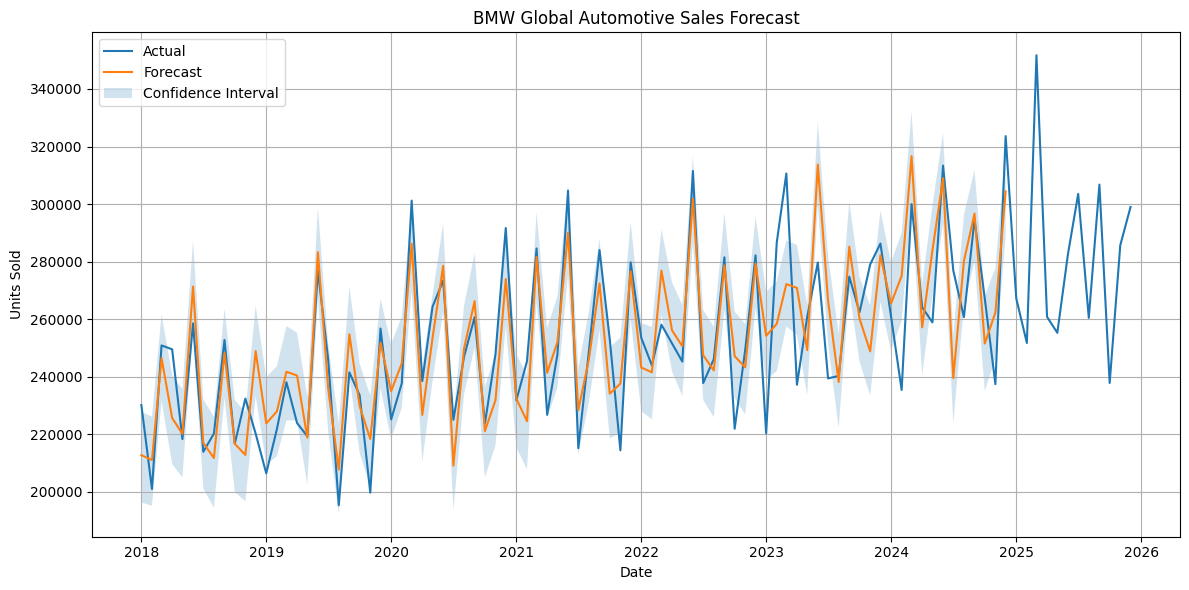

In [178]:
plt.figure(figsize=(12, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='Actual')
plt.plot(forecast_24['ds'], forecast_24['yhat'], label='Forecast')
plt.fill_between(
    forecast_24['ds'],
    forecast_24['yhat_lower'],
    forecast_24['yhat_upper'],
    alpha=0.2,
    label='Confidence Interval'
)
plt.legend()
plt.title('BMW Global Automotive Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.grid(True)
plt.tight_layout()
plt.show()


## Final Insights

Sales are projected to remain broadly stable over the next 24 months, with seasonal fluctuations continuing to appear in the forecast rather than a dramatic step-change in demand. The historical series already shows recurring stronger months such as March, June, September, and December, and weaker months such as January, August, and October, and the Prophet forecast preserves that general pattern.

Based on the saved holdout evaluation already present in this notebook, **Exponential Smoothing performed best** with the lowest error (`MAE ≈ 22,187`, `RMSE ≈ 27,416`). `ARIMA` ranked second (`RMSE ≈ 30,665`), while `Prophet` had the highest error (`RMSE ≈ 40,326`). That means Prophet is useful for visualizing trend and seasonality here, but Exponential Smoothing is the strongest baseline model in the current notebook results.
